In [1]:
from src.deep_learning.op import MULTIPLY
from src.deep_learning.op import PLUS
from src.deep_learning.value import Value
from src.deep_learning.util import draw

a = Value(2, label='a')
b = Value(3, label='b')
c = Value(label='c', children=[a, b], op=PLUS)

d = Value(5, label='d')
e = Value(6, label='e')
f = Value(label='f', children=[d, e], op=MULTIPLY)

L = Value(label='L', children=[c, f], op=PLUS)

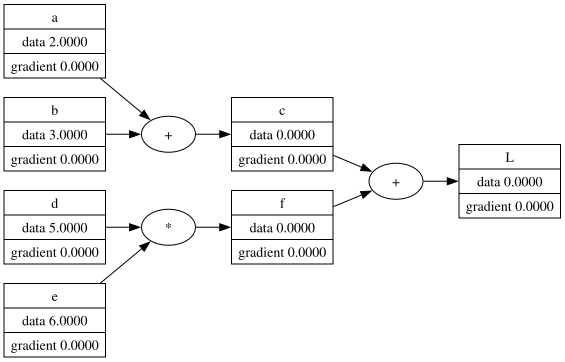

In [2]:
draw(L)

In [3]:
L.forward()

Value({'data': 35.0, 'label': 'L', 'op': +, 'children': [Value({'data': 5.0, 'label': 'c', 'op': +, 'children': [Value({'data': 2.0, 'label': 'a', 'op': None, 'children': [], 'gradient': 0.0}), Value({'data': 3.0, 'label': 'b', 'op': None, 'children': [], 'gradient': 0.0})], 'gradient': 0.0}), Value({'data': 30.0, 'label': 'f', 'op': *, 'children': [Value({'data': 5.0, 'label': 'd', 'op': None, 'children': [], 'gradient': 0.0}), Value({'data': 6.0, 'label': 'e', 'op': None, 'children': [], 'gradient': 0.0})], 'gradient': 0.0})], 'gradient': 0.0})

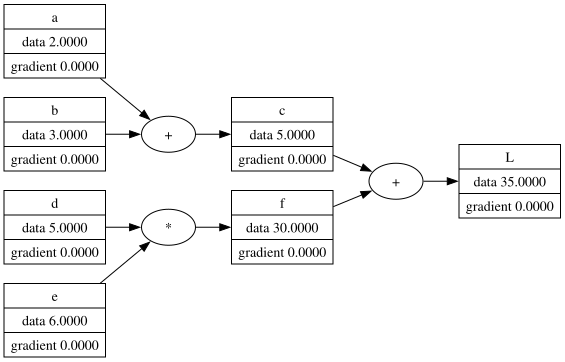

In [4]:
draw(L)

In [5]:
L.gradient = 1.0
L.backward()

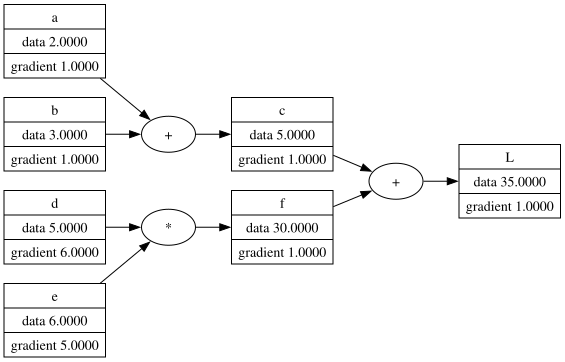

In [6]:
draw(L)

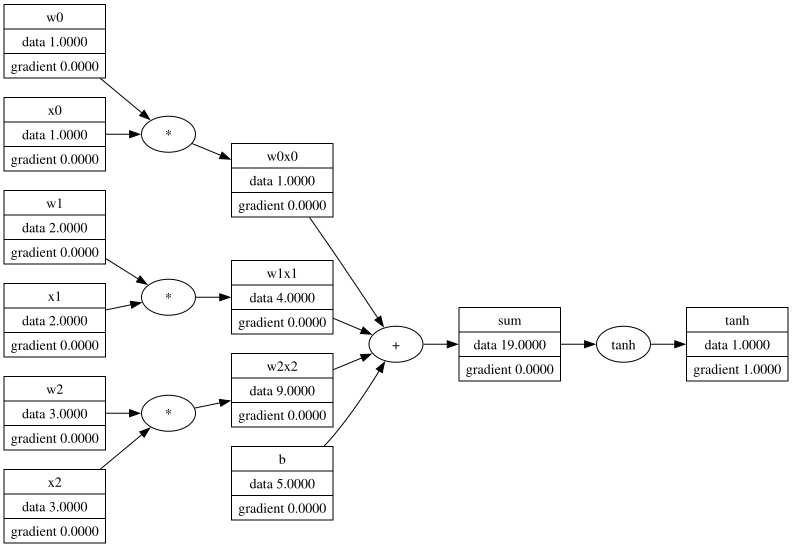

In [7]:
from src.deep_learning.neuron import Neuron
from src.deep_learning.value import Value
from src.deep_learning.util import draw
from src.deep_learning.op import TANH

neuron = Neuron(
    weights=[1.0, 2.0, 3.0],
    bias=5.0,
    activation=TANH,
)
value = neuron.build_graph(
    inputs=[1.0, 2.0, 3.0],
)
value.forward()
assert value.data == TANH.forward([1.0 ** 2 + 2.0 ** 2 + 3.0 ** 2 + 5.0])

value.gradient = 1.0
value.backward()
draw(value)

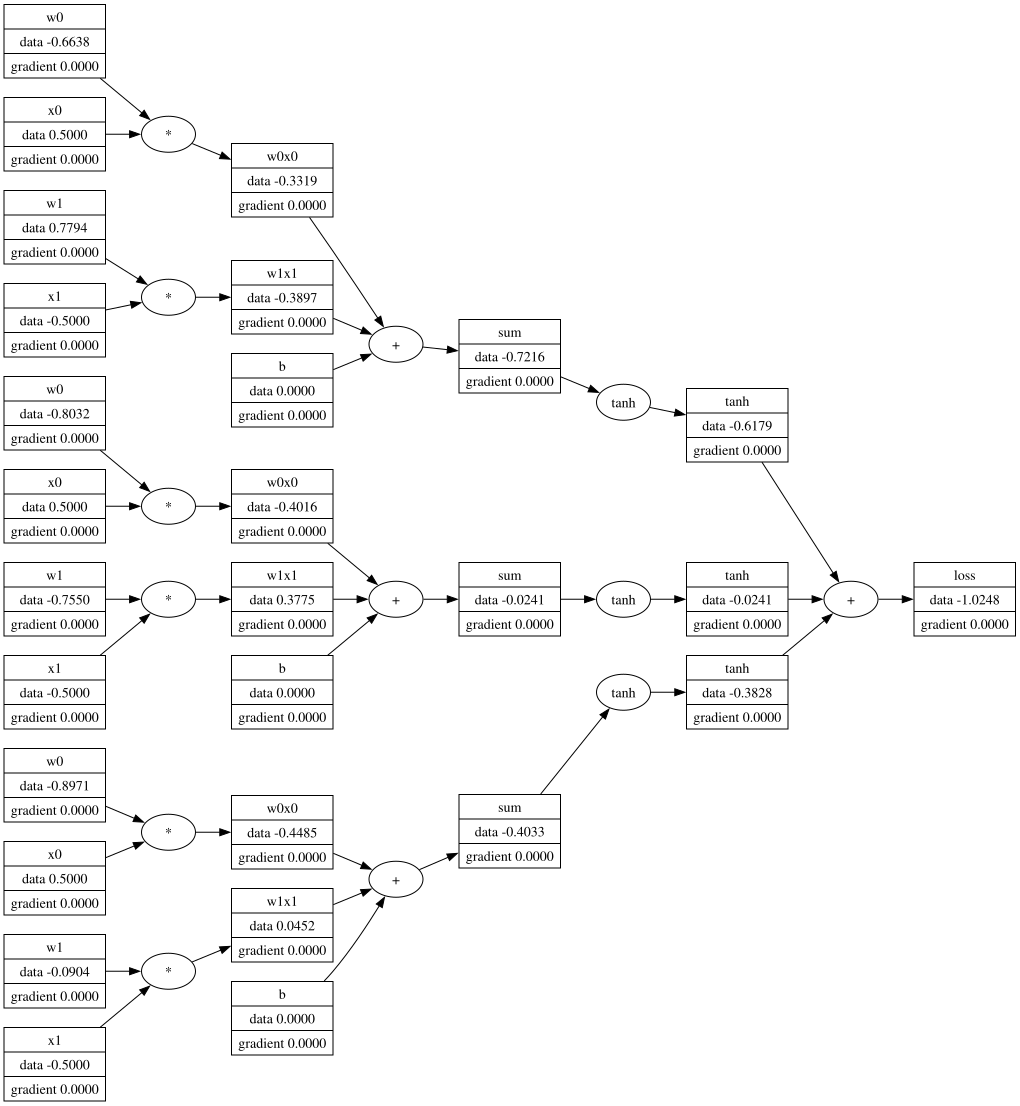

In [8]:
from src.deep_learning.op import PLUS
from src.deep_learning.layer import get_layer

layer = get_layer(
    num_weights_per_neuron=2,
    num_neurons=3,
    activation=TANH,
)
inputs = [0.5, -0.5]
outputs = layer.build_graph(inputs)

loss = Value(
    label='loss',
    op=PLUS,
    children=outputs,
)
loss.forward()

draw(loss)

In [ ]:
from src.deep_learning.multi_layer_perceptron import MultiLayerPerceptron
from src.deep_learning.util import xavier_uniform
from src.deep_learning.util import mean_squared_error
from src.deep_learning.util import zero_all_gradients

class Data:
  def __init__(self, inputs: list[float], outputs: list[float]):
    self.inputs = inputs
    self.outputs = outputs

data = [
    Data([2.0, 3.0, -1.0], [1.0]),
    Data([3.0, -1.0, 0.5], [-1.0]),
    Data([0.5, 1.0, 1.0], [-1.0]),
    Data([1.0, 1.0, -1.0], [1.0]),
]

input_values = [Value(0.0, label=f'x{i}') for i in range(len(data[0].inputs))]
output_values = [Value(0.0, label=f'output')]

multi_layer_perceptron = MultiLayerPerceptron(
    layers=[
        get_layer(
            num_weights_per_neuron=3,
            num_neurons=4,
            activation=TANH,
            fn_weight_initializer=lambda: xavier_uniform(num_inputs=3, num_outputs=4),
        ),
        get_layer(
            num_weights_per_neuron=4,
            num_neurons=4,
            activation=TANH,
            fn_weight_initializer=lambda: xavier_uniform(num_inputs=4, num_outputs=4),
        ),
        get_layer(
            num_weights_per_neuron=4,
            num_neurons=1,
        ),
    ],
)
predicted_outputs = multi_layer_perceptron.build_graph(input_values)
loss = mean_squared_error(
    outputs=output_values,
    predicted_outputs=predicted_outputs,
)

In [10]:
losses: list[float] = []

In [11]:
for d in data:
  for input, value in zip(d.inputs, input_values, strict=True):
    value.data = input
  for output, value in zip(d.outputs, output_values, strict=True):
    value.data = output

  loss.forward()
  print(f'predicted={predicted_outputs[0].data:4f}, desired={d.outputs[0]}')

predicted=0.265352, desired=1.0
predicted=-0.567409, desired=-1.0
predicted=0.548638, desired=-1.0
predicted=-0.030302, desired=1.0


In [ ]:
for i in range(10000):
  losses_per_epoch: list[float] = []
  for d in data:
    
    # compute loss
    for input, value in zip(d.inputs, input_values, strict=True):
      value.data = input
    for output, value in zip(d.outputs, output_values, strict=True):
      value.data = output
    
    loss.forward()

    losses_per_epoch.append(loss.data)

    # backwards
    zero_all_gradients(loss)
    loss.gradient = 1.0
    loss.backward()

    # update parameters
    alpha = 0.01
    for layer in multi_layer_perceptron.layers:
      for neuron in layer.neurons:
        for weight_value in neuron.weight_values:
          weight_value.data = weight_value.data - weight_value.gradient * alpha
        neuron.bias_value.data = neuron.bias_value.data - neuron.bias_value.gradient * alpha
  
  losses.append(sum(losses_per_epoch) / len(losses_per_epoch))

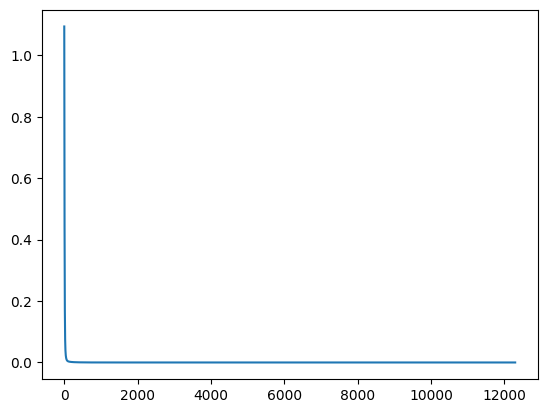

In [28]:
import matplotlib.pyplot as plt

plt.plot(losses)

In [29]:
for d in data:
  for input, value in zip(d.inputs, input_values, strict=True):
    value.data = input
  for output, value in zip(d.outputs, output_values, strict=True):
    value.data = output

  loss.forward()
  print(f'predicted={predicted_outputs[0].data:4f}, desired={d.outputs[0]}')

predicted=1.000000, desired=1.0
predicted=-1.000000, desired=-1.0
predicted=-1.000000, desired=-1.0
predicted=1.000000, desired=1.0
